### 선형회귀(Linear Regression)

In [4]:
# 당뇨병 데이터
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()


In [6]:
# 입력데이터와 타깃 데이터
print(diabetes.data.shape)
print(diabetes.target.shape)

(442, 10)
(442,)


In [7]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [8]:
diabetes.target[0:3]

array([151.,  75., 141.])

### 컬럼
- age : 환자의 나이
- sex : 성별
- bmi : 체질량 지수
- bp : 평균 혈압
- s1 : 혈청 수치(HDL 콜레스테롤 수치)
- s2 : 혈청 수치(LDL 콜레스테롤 수치)
- s3 : 혈청 수치(총 콜레스테롤 수치)
- s4 : 혈청 수치(혈청 트리 그리세이드 수치)
- s5 : 혈청 수치 (혈당 수치)
- s6 : 혈청 수치(기타 혈액 측정 수치)
: diabeetes의 target은 1년후의 당뇨병 진행 상황을 수치화 한 것

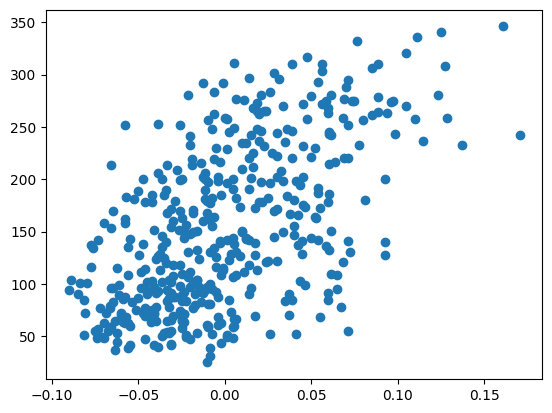

In [9]:
# bmi 시각화
import matplotlib.pyplot as plt

plt.scatter(
  diabetes.data[:,2],
  diabetes.target
)

plt.show()

### 예측값(y^)으로 올바른 모델 찾기
- 훈련데이터에 잘 맞는 w와 b를 찾는 방법(Y^=wX+b)
1) 무작위로 w와 b를 정한다.
2) X에서 샘플 하나를 선택하여 Y^을 계산한다. (정방향 계산)
3) Y^과 선택한 샘플의 Y값을 비교한다. (예측값과 정답값 비교 : 손실함수)
4) Y^이 Y와 가까워지도록 w, b를 조정한다. (모델 조정 : 역방향계산)
5) 모든 샘플이 처리될때까지 다시 2) ~ 5) 항목을 반복한다.

In [11]:
# 데이터 준비
x = diabetes.data[:,2]
y = diabetes.target

In [12]:
# 초기의 w와 b를 정하기
w = b = 1.0

In [13]:
# 첫번째 샘플로 계산하기
y_hat = w*x[0] + b
y_hat

1.0616962065186832

In [14]:
# 실제 값
y[0]

151.0

In [15]:
# 실제값과 가까워지기 위해 w와 b를 조금씩 변경해서 y_hat 이 증가하는지 감소하는지 파악
# w를 0.1 만큼 증가하자

w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
y_hat_inc

1.0678658271705517

In [16]:
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

0.06169620651868429

### 변화율은 결국 훈련데이터의 샘플이다.

#### 변화율(Gradient : 경사, 기울기, 가중치)로 가중치 및 절편 업데이트 하기

In [17]:
w_new = w + w_rate
w_new

1.0616962065186843

In [19]:
b_rate = 1

In [20]:
b_new = b + 1
b_new

2

---
#### 오차 역전파(back propagation)로 가중치와 절편을 더 적절하게 업데이트 하기
: 오차와 변화율을 곱하여 가중치 업데이트

In [21]:
err = y[0] - y_hat
w_new = w + w_rate * err # 변화율에 오차를 곱한다.
b_new = b + 1 * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [22]:
# x[1]
y_hat = x[1] * w_new + b_new
err = y[1] - y_hat

w_rate = x[1]
w_new = w_new + w_rate * err
b_new = b_new + 1 * err
print(w_new, b_new)

14.132317616380695 75.52764127612656


In [24]:
# x[2]
y_hat = x[2] * w_new + b_new
err = y[2] - y_hat

w_rate = x[2]
w_new = w_new + w_rate * err
b_new = b_new + 1 * err
print(w_new, b_new)

17.00902384158754 140.2436750865885


### 전체 샘플을 반복하기

In [26]:
w = b = 1

for x_i, y_i in zip(x, y):
  y_hat = x_i * w + b
  err = y_i - y_hat
  w_rate = x_i
  w = w + w_rate * err
  b = b + 1 * err

print(w,b)

587.8654539985616 99.4093556453094


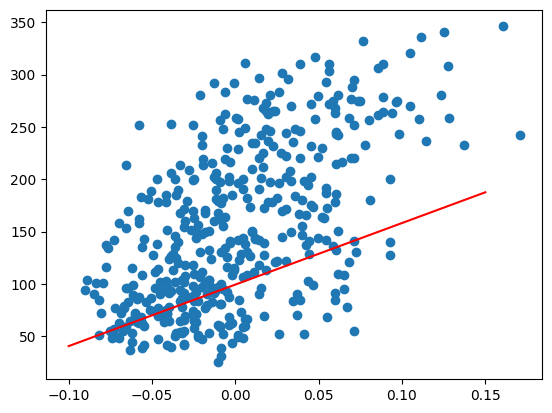

In [28]:
# 산점도에 직선을 넣어 잘 되었는지 확인하기
plt.scatter(
  x,
  y
)

pt1 = (-0.1, -0.1*w+b)
pt2 = (0.15, 0.15*w+b)

plt.plot(
  [pt1[0], pt2[0]],
  [pt1[1], pt2[1]],
  color='red'
)

plt.show()

### Epoch로 반복하기
: 경사하강법에서는 보통 주어진 훈련데이터로 학습을 여러번 반복한다.

In [29]:
# Epoch를 100으로 하기



w = b = 1


for _ in range(100):
  for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w_rate = x_i
    w = w + w_rate * err
    b = b + 1 * err

print(w,b)

913.5973364346786 123.39414383177173


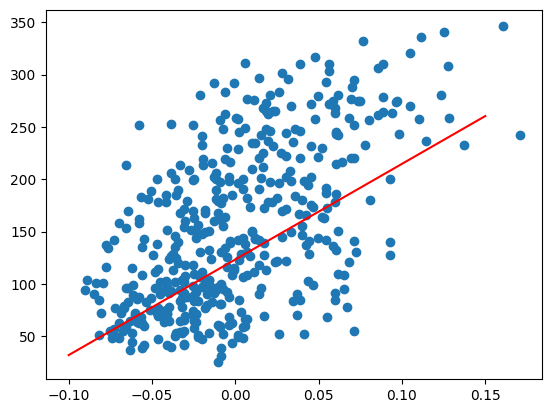

In [30]:
# 산점도에 직선을 넣어 잘 되었는지 확인하기
plt.scatter(
  x,
  y
)

pt1 = (-0.1, -0.1*w+b)
pt2 = (0.15, 0.15*w+b)

plt.plot(
  [pt1[0], pt2[0]],
  [pt1[1], pt2[1]],
  color='red'
)

plt.show()

----
### 손실함수와 경사 하강법
#### 손실함수(비용함수)?
- 예상한 값과 실제값의 차이를 함수로 정의한 것    
- 손실함수의 차이를 줄이는 방법으로 경사하강법을 사용   
- 대표적인 회귀(regression), 분류(classfication)등에서 널리 사용하는 손실함수가 있습니다.   
- 복잡한 다른 문제에서는 자신만의 손실함수를 정의하여 사용기도 합니다.      


### 회귀의 손실함수
- 제곱오차(Squared Error)를 사용    
: 타깃값과 예측값을 뺀 다음 제곱한 것이다(음수가 발생할 수 있기 때문에)   
SE = (y - y^)<sup>2</sup>

In [36]:
class Neuron:
  # 초기화 작업
  def __init__(self):
    self.w = 1.0 # 가중치를 초기화
    self.b = 1.0 # 절편을 초기화


  def forpass(self, x):
    y_hat = x * self.w + self.b
    return y_hat
  
  def backprop(self, x, err):
    w_grad = x * err
    b_grad = 1 * err
    return w_grad, b_grad

  def fit(self, x, y, epochs=100):
    for _ in range(epochs):
      for x_i, y_i in zip(x, y):
        y_hat = self.forpass(x_i) # 정방향 계산
        err = (y_i - y_hat) # 오차 -> 손실함수
        w_grad, b_grad = self.backprop(x_i, err) # 역방향 계산
        self.w += w_grad
        self.b += b_grad
    return self.w, self.b

In [38]:
# 사용하기
neuron = Neuron()
w, b = neuron.fit(x, y, epochs=100)
print(w, b)

913.5973364346786 123.39414383177173
